In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = r"C:\sourcecode\Nhom_10_Big_Data"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from pyspark.sql import functions as F

from src.config.spark_session import get_spark
from src.config.hdfs_config import SUPERSTORE_DATASET
from src.config.schema import SUPERSTORE_SCHEMA

spark = get_spark()
spark.sparkContext.setLogLevel("WARN")

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "images", "eda")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Spark đã khởi tạo.")
print("HDFS path:", SUPERSTORE_DATASET)
print("Thư mục lưu biểu đồ:", OUTPUT_DIR)

Spark đã khởi tạo.
HDFS path: hdfs://master:9000/bigdata/superstore/input/G10_dataset.csv
Thư mục lưu biểu đồ: C:\sourcecode\Nhom_10_Big_Data\images\eda


In [2]:
df = (
    spark.read
    .option("header", "true")
    .option("dateFormat", "yyyy-MM-dd")
    .option("multiLine", "true")
    .option("quote", '"')
    .option("escape", '"')
    .option("mode", "PERMISSIVE")
    .schema(SUPERSTORE_SCHEMA)
    .csv(SUPERSTORE_DATASET)
)

df.cache()

print("Rows:", df.count())
print("Cols:", len(df.columns))

df.printSchema()
df.show(5, truncate=False)

Rows: 500000
Cols: 24
root
 |-- Category: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- Customer_Name: string (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Market: string (nullable = true)
 |-- Order_Date: date (nullable = true)
 |-- Order_ID: string (nullable = true)
 |-- Order_Priority: string (nullable = true)
 |-- Product_ID: string (nullable = true)
 |-- Product_Name: string (nullable = true)
 |-- Profit: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Ship_Date: date (nullable = true)
 |-- Ship_Mode: string (nullable = true)
 |-- Shipping_Cost: double (nullable = true)
 |-- State: string (nullable = true)
 |-- Sub_Category: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- weeknum: integer (nullable = true)

+--

In [3]:
df_eda = (
    df
    .withColumn("Order_Date", F.to_date("Order_Date"))
    .withColumn("Ship_Date", F.to_date("Ship_Date"))
    .withColumn("Sales", F.col("Sales").cast("double"))
    .withColumn("Profit", F.col("Profit").cast("double"))
    .withColumn("Quantity", F.col("Quantity").cast("int"))
    .withColumn("Discount", F.col("Discount").cast("double"))
    .withColumn("Shipping_Cost", F.col("Shipping_Cost").cast("double"))
    .withColumn("Year", F.col("Year").cast("int"))
    .withColumn("weeknum", F.col("weeknum").cast("int"))
    .withColumn("Year_Month", F.date_format(F.col("Order_Date"), "yyyy-MM"))
)

df_eda.cache()

df_eda.select(
    "Order_Date", "Year_Month", "Sales", "Profit", "Quantity", "Discount", "Shipping_Cost"
).show(5, truncate=False)

+----------+----------+-----+-------+--------+--------+-------------+
|Order_Date|Year_Month|Sales|Profit |Quantity|Discount|Shipping_Cost|
+----------+----------+-----+-------+--------+--------+-------------+
|2011-01-07|2011-01   |19.0 |9.3312 |3       |0.0     |4.37         |
|2011-01-21|2011-01   |19.0 |9.2928 |2       |0.0     |0.94         |
|2011-08-05|2011-08   |21.0 |9.8418 |3       |0.0     |1.81         |
|2011-08-05|2011-08   |111.0|53.2608|2       |0.0     |4.59         |
|2011-09-29|2011-09   |6.0  |3.1104 |1       |0.0     |1.32         |
+----------+----------+-----+-------+--------+--------+-------------+
only showing top 5 rows


In [4]:
numeric_cols = ["Sales", "Profit", "Quantity", "Discount", "Shipping_Cost"]

desc_pdf = df_eda.select(numeric_cols).describe().toPandas()

display(desc_pdf)

,summary,Sales,Profit,Quantity,Discount,Shipping_Cost
0,count,500000,500000,500000,500000,500000
1,mean,272.6786451800033,20.7916697225599,3.530394,0.17052139599996002,30.00976650680023
2,stddev,552.6722123536562,168.90676575248264,2.334580712954299,0.1300124068874319,67.71452283478307
3,min,0.36,-6599.978,1,0.0,0.0
4,max,31357.32,12756.9,14,0.85,1784.71


,Market,Total_Sales,Total_Profit,Transaction_Count
0,EU,37196255.45,2902240.20,134052
1,APAC,26774692.64,2069447.71,95589
2,LATAM,22569056.36,1700221.11,84504
3,US,21598622.51,1702466.68,79824
4,EMEA,15524409.41,1077575.96,58359
5,Africa,11081418.17,814160.89,42028
6,Canada,1594868.05,129722.31,5644


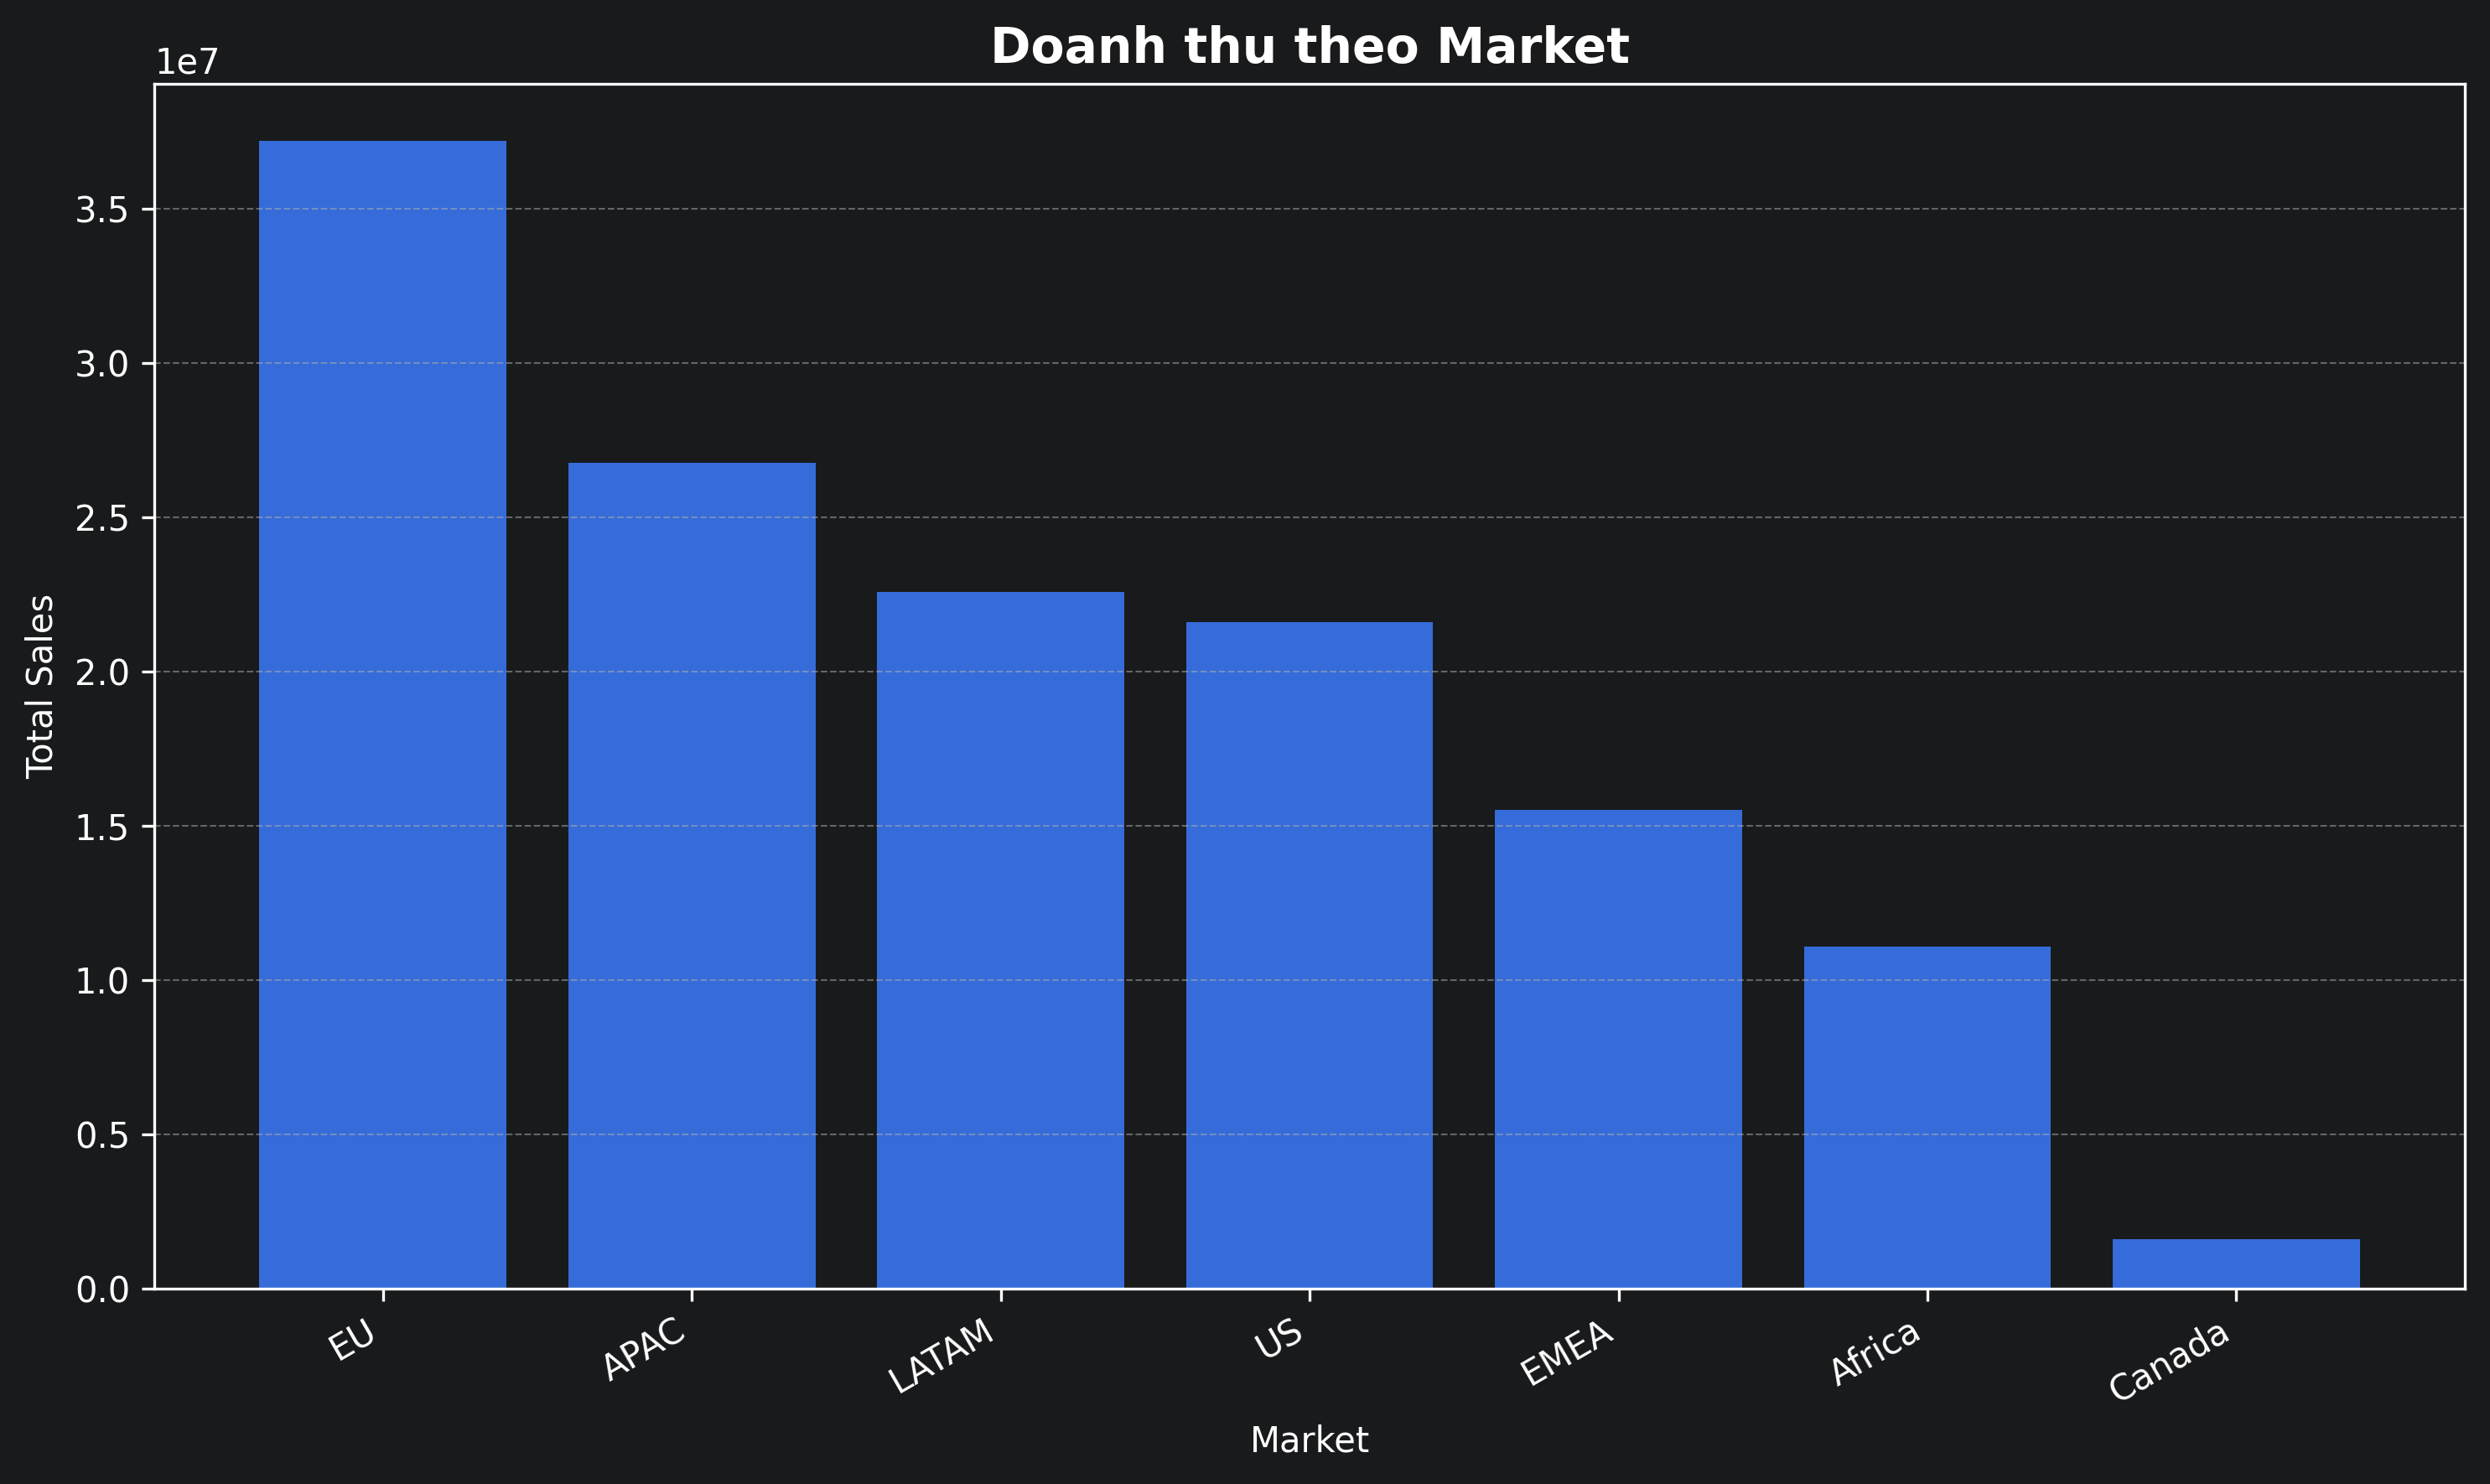

Đã lưu: C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_market_sales.png


In [5]:
market_sales_pdf = (
    df_eda
    .groupBy("Market")
    .agg(
        F.round(F.sum("Sales"), 2).alias("Total_Sales"),
        F.round(F.sum("Profit"), 2).alias("Total_Profit"),
        F.count("*").alias("Transaction_Count")
    )
    .orderBy(F.desc("Total_Sales"))
    .toPandas()
)

display(market_sales_pdf)

plt.figure(figsize=(10, 6), dpi=300)
plt.bar(market_sales_pdf["Market"], market_sales_pdf["Total_Sales"])
plt.title("Doanh thu theo Market", fontsize=14, fontweight="bold")
plt.xlabel("Market")
plt.ylabel("Total Sales")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

output_path = os.path.join(OUTPUT_DIR, "eda_market_sales.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", output_path)

,Category,Total_Sales,Total_Profit
0,Technology,50824516.06,4965266.89
1,Furniture,44577253.32,1434577.60
2,Office Supplies,40937553.21,3995990.36


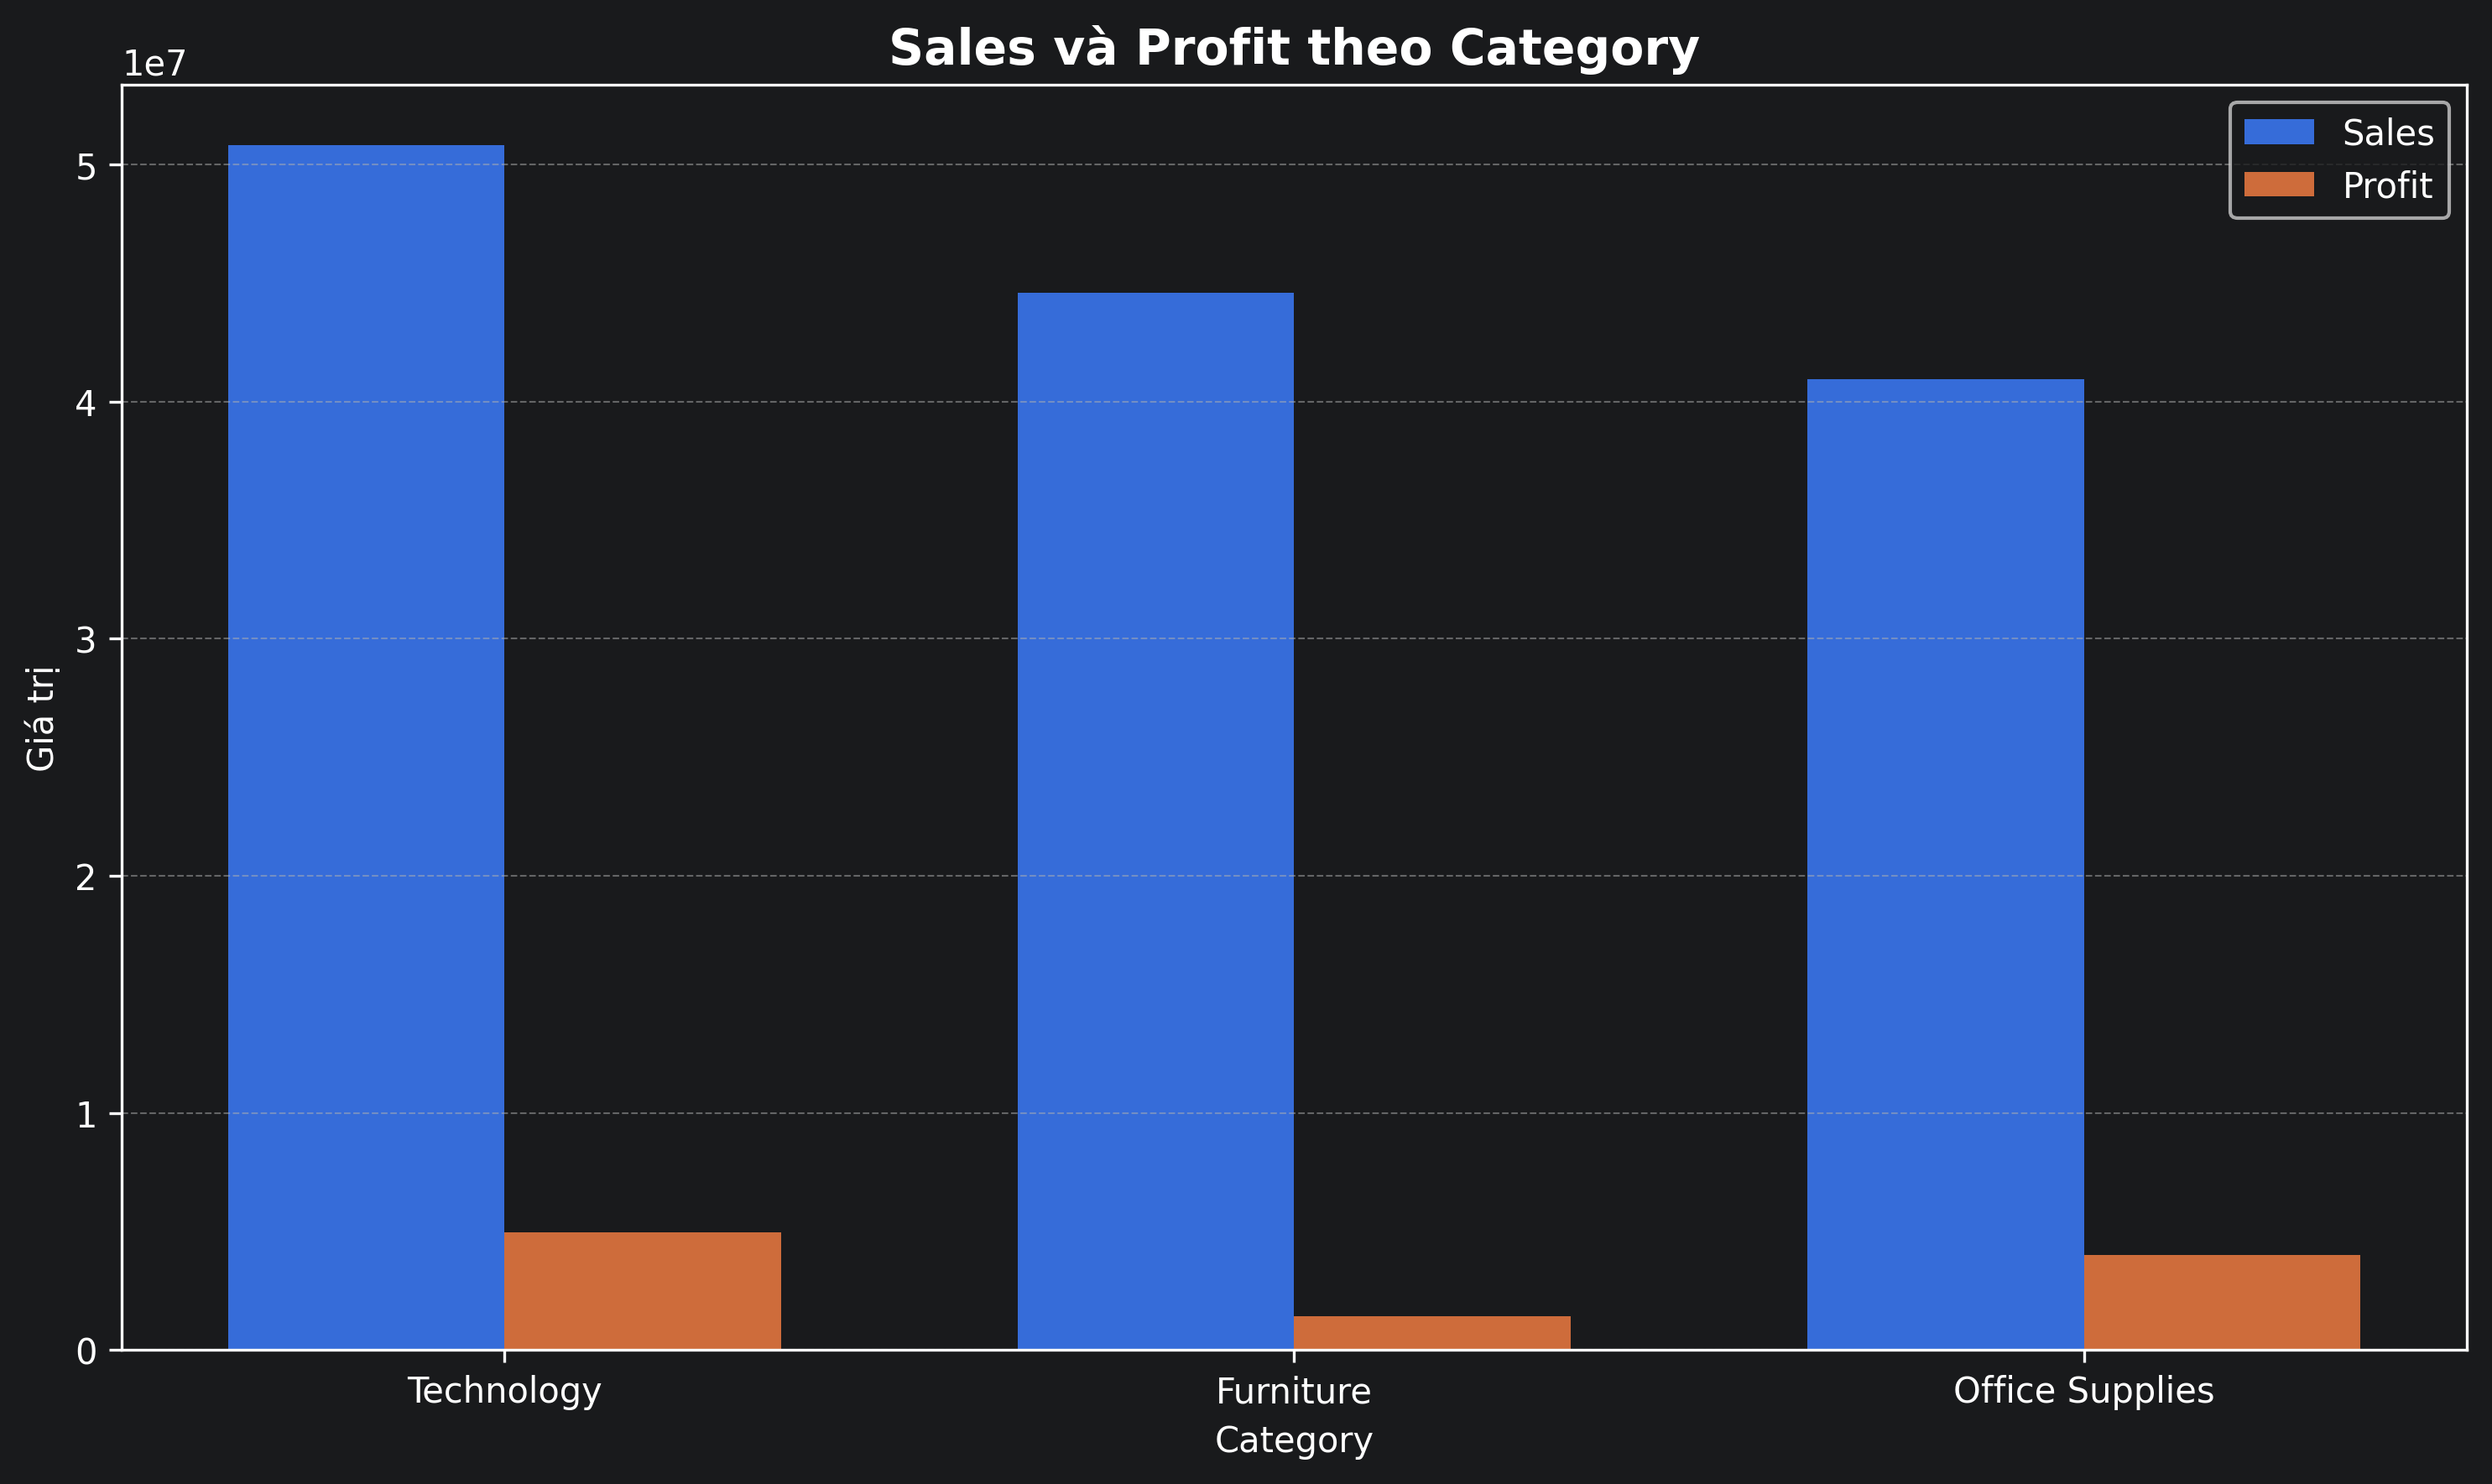

Đã lưu: C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_category_sales_profit.png


In [6]:
category_pdf = (
    df_eda
    .groupBy("Category")
    .agg(
        F.round(F.sum("Sales"), 2).alias("Total_Sales"),
        F.round(F.sum("Profit"), 2).alias("Total_Profit")
    )
    .orderBy(F.desc("Total_Sales"))
    .toPandas()
)

display(category_pdf)

x = np.arange(len(category_pdf["Category"]))
width = 0.35

plt.figure(figsize=(10, 6), dpi=300)
plt.bar(x - width/2, category_pdf["Total_Sales"], width, label="Sales")
plt.bar(x + width/2, category_pdf["Total_Profit"], width, label="Profit")

plt.title("Sales và Profit theo Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Giá trị")
plt.xticks(x, category_pdf["Category"], rotation=0)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

output_path = os.path.join(OUTPUT_DIR, "eda_category_sales_profit.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", output_path)

,Segment,Total_Sales,Transaction_Count
0,Consumer,57994899.12,212803
1,Corporate,44424354.11,162548
2,Home Office,33920069.36,124649


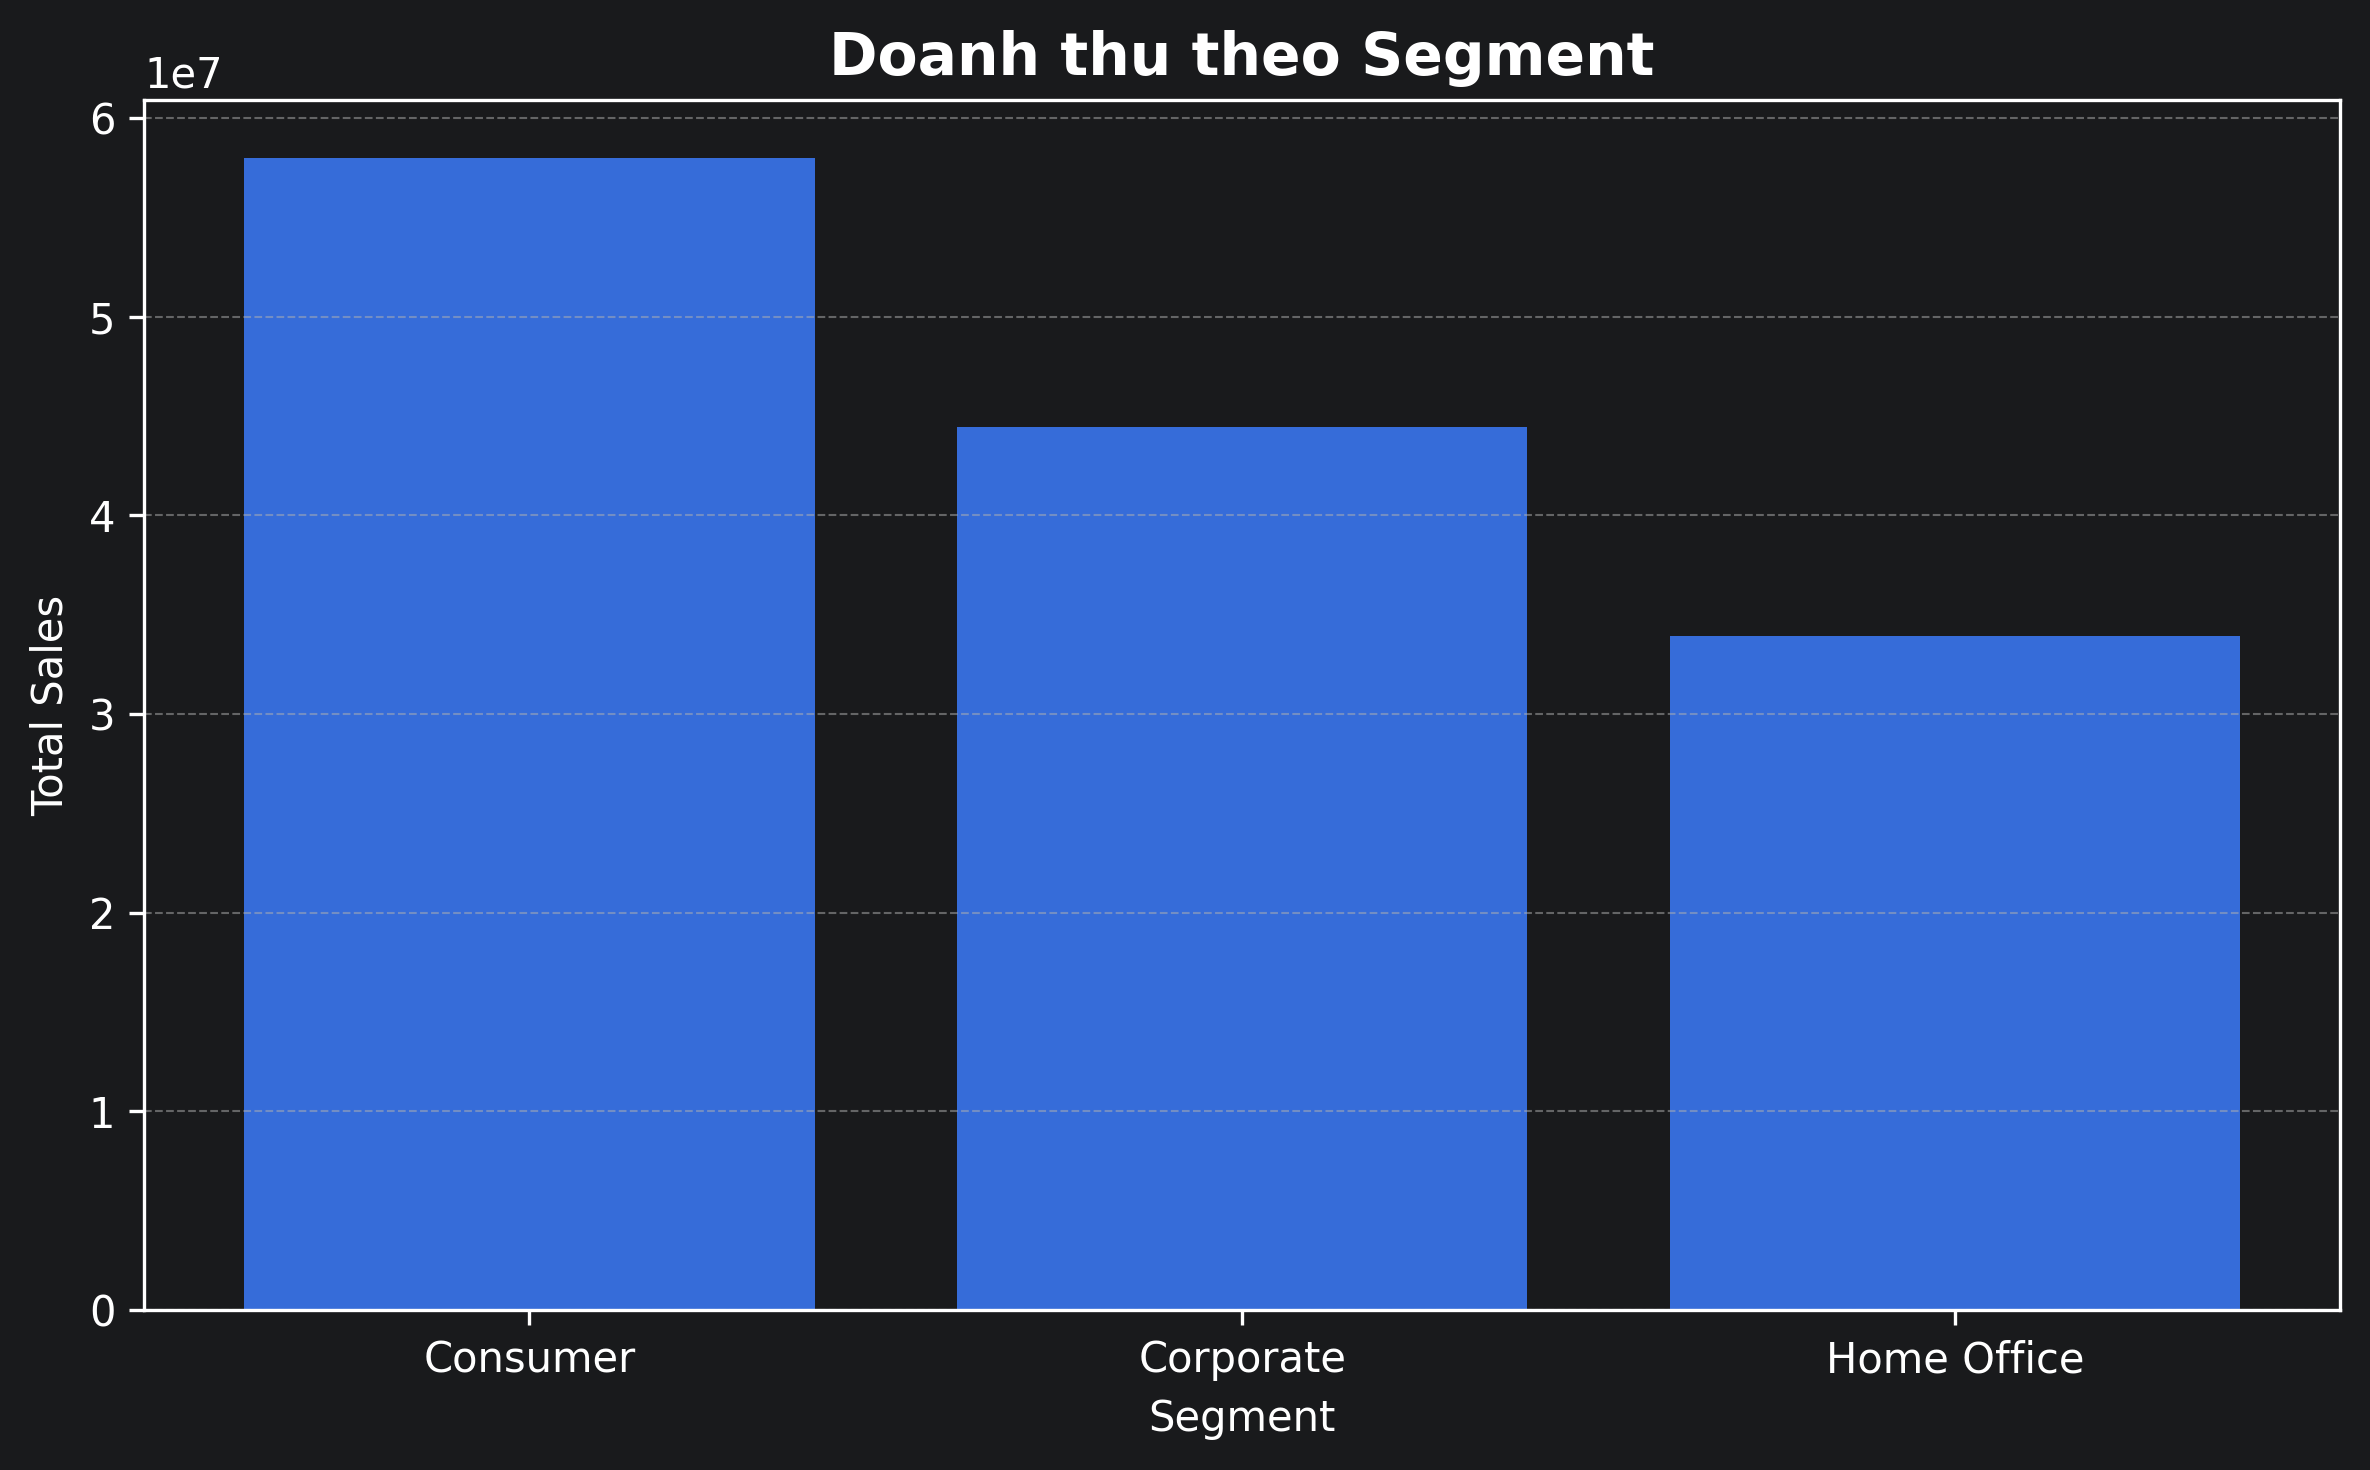

Đã lưu: C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_segment_sales.png


In [7]:
segment_pdf = (
    df_eda
    .groupBy("Segment")
    .agg(
        F.round(F.sum("Sales"), 2).alias("Total_Sales"),
        F.count("*").alias("Transaction_Count")
    )
    .orderBy(F.desc("Total_Sales"))
    .toPandas()
)

display(segment_pdf)

plt.figure(figsize=(8, 5), dpi=300)
plt.bar(segment_pdf["Segment"], segment_pdf["Total_Sales"])
plt.title("Doanh thu theo Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

output_path = os.path.join(OUTPUT_DIR, "eda_segment_sales.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", output_path)

,Year_Month,Monthly_Sales,Monthly_Profit
0,2011-01,321950.39,16712.87
1,2011-02,336361.42,13923.92
2,2011-03,516508.79,31225.08
3,2011-04,573510.51,26973.76
4,2011-05,703295.22,28807.60


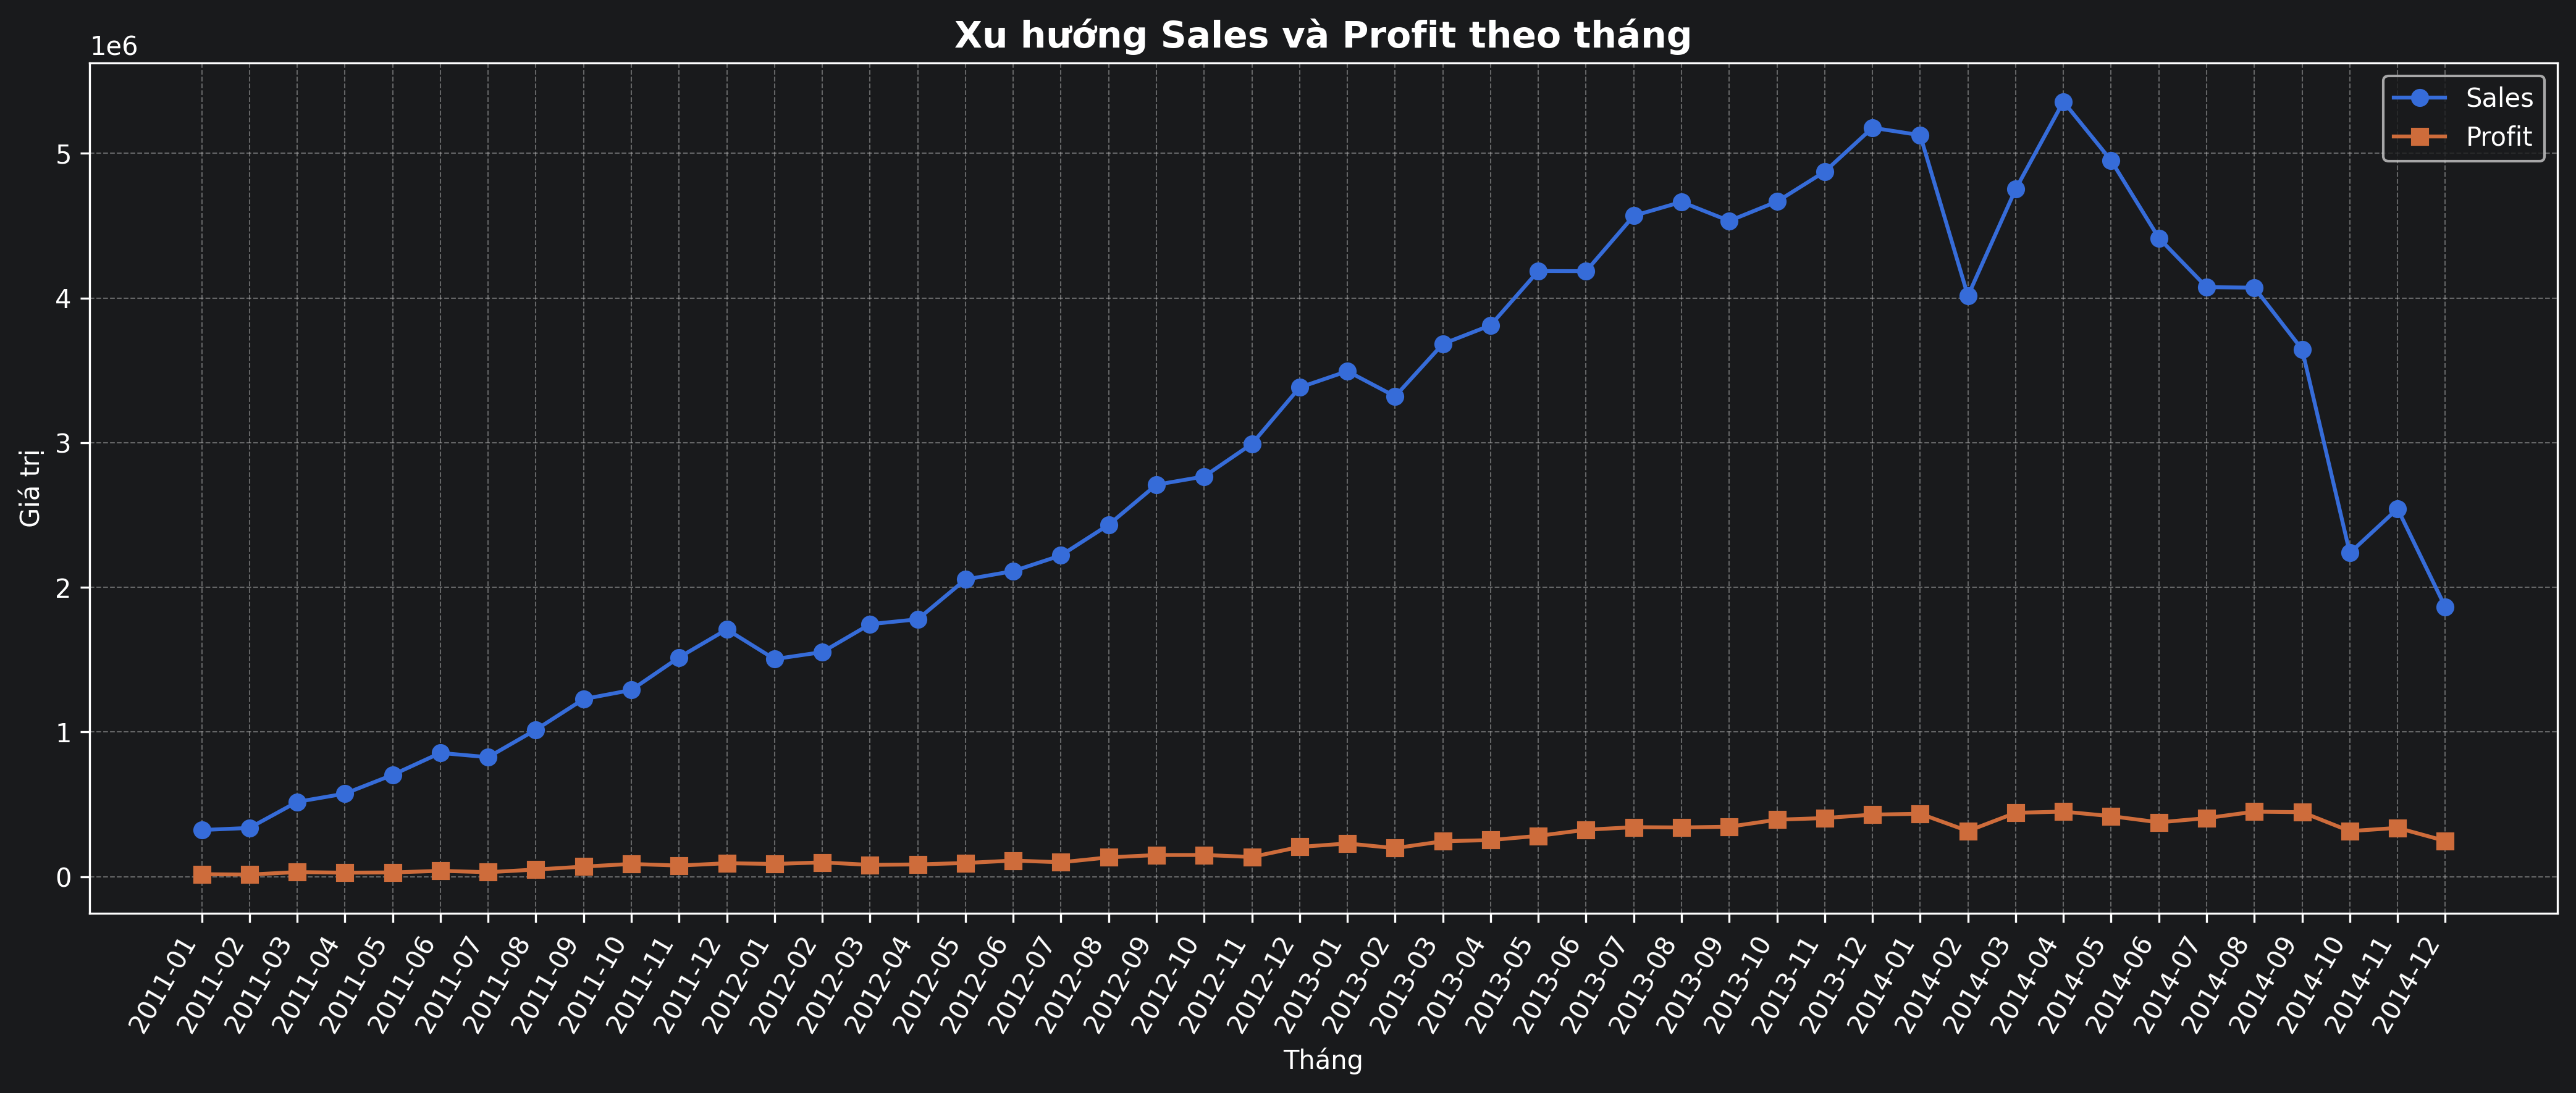

Đã lưu: C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_monthly_sales_profit_trend.png


In [8]:
monthly_pdf = (
    df_eda
    .groupBy("Year_Month")
    .agg(
        F.round(F.sum("Sales"), 2).alias("Monthly_Sales"),
        F.round(F.sum("Profit"), 2).alias("Monthly_Profit")
    )
    .orderBy("Year_Month")
    .toPandas()
)

display(monthly_pdf.head())

plt.figure(figsize=(14, 6), dpi=300)
plt.plot(monthly_pdf["Year_Month"], monthly_pdf["Monthly_Sales"], marker="o", label="Sales")
plt.plot(monthly_pdf["Year_Month"], monthly_pdf["Monthly_Profit"], marker="s", label="Profit")

plt.title("Xu hướng Sales và Profit theo tháng", fontsize=14, fontweight="bold")
plt.xlabel("Tháng")
plt.ylabel("Giá trị")
plt.xticks(rotation=60, ha="right")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

output_path = os.path.join(OUTPUT_DIR, "eda_monthly_sales_profit_trend.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", output_path)

,Discount_Bucket,Avg_Profit,Avg_Sales,Transaction_Count
3,0,57.34,249.92,35890
0,0-10%,39.37,293.12,144441
4,10-20%,25.71,286.13,146647
6,20-30%,6.80,262.66,99137
5,30-40%,-10.46,247.31,51473
1,40-50%,-47.17,207.80,10647
2,>50%,-63.99,177.56,11765


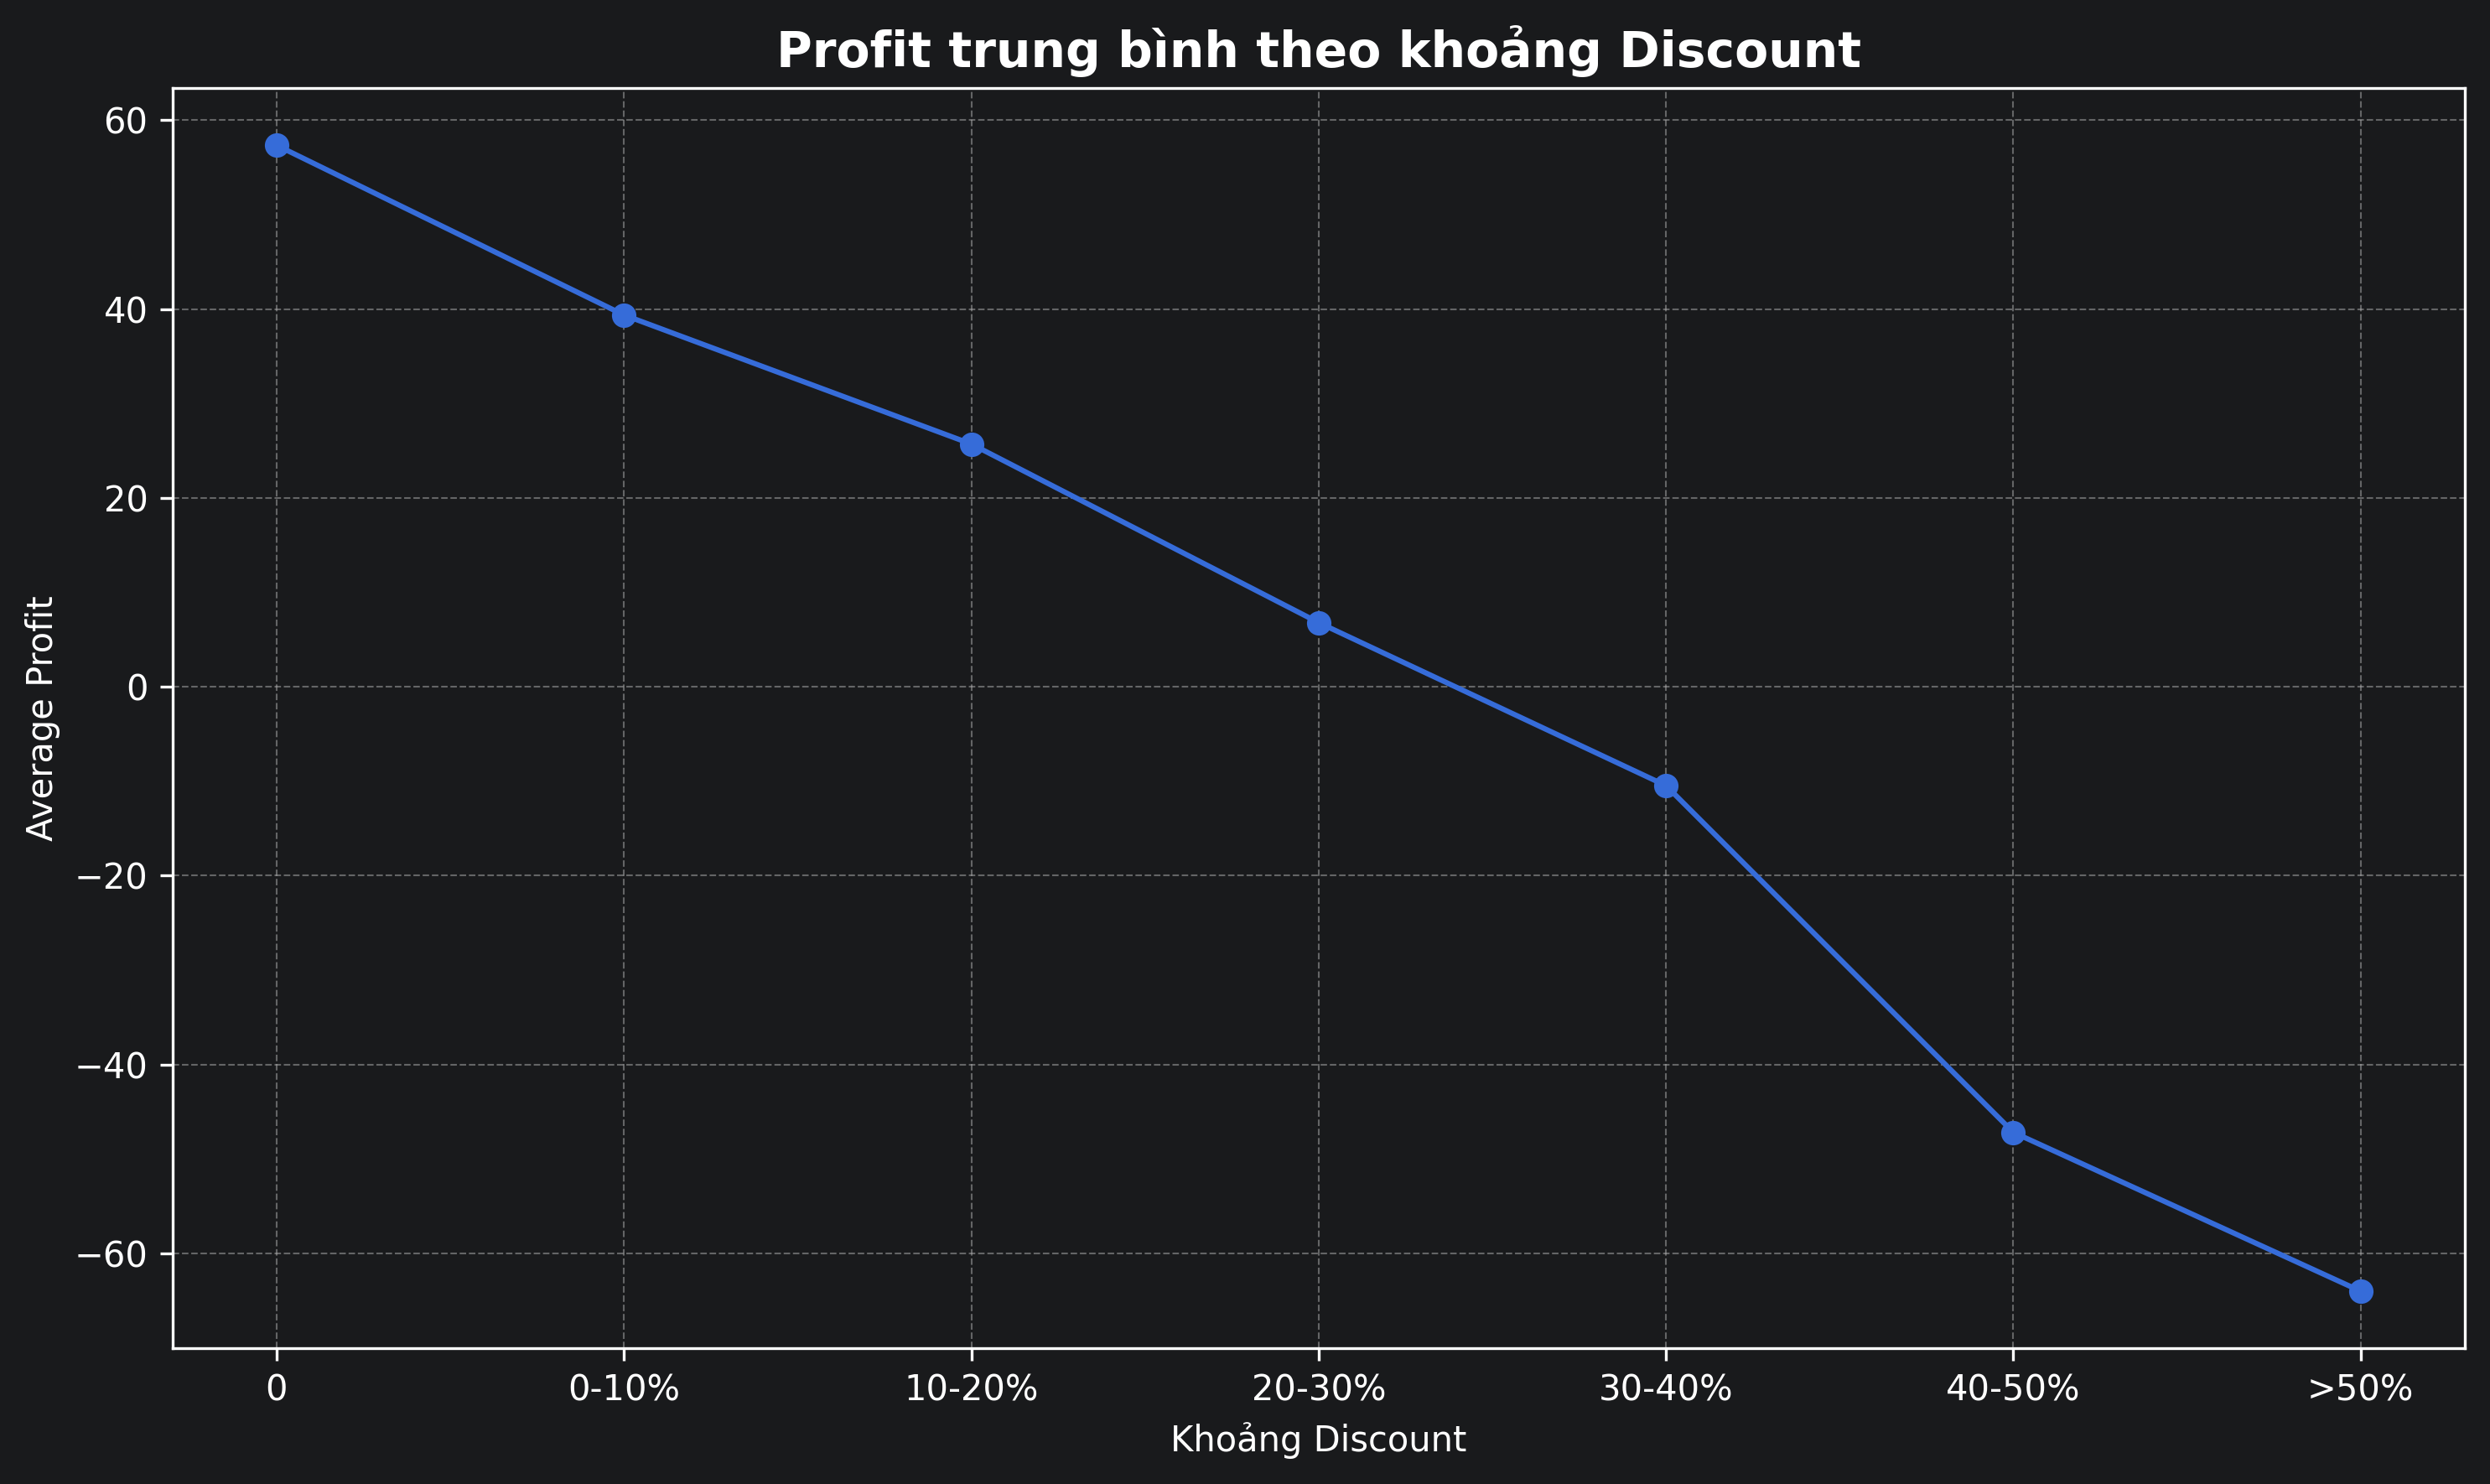

Đã lưu: C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_discount_avg_profit.png


In [9]:
df_discount_bucket = (
    df_eda
    .withColumn(
        "Discount_Bucket",
        F.when(F.col("Discount") == 0, "0")
         .when((F.col("Discount") > 0) & (F.col("Discount") <= 0.1), "0-10%")
         .when((F.col("Discount") > 0.1) & (F.col("Discount") <= 0.2), "10-20%")
         .when((F.col("Discount") > 0.2) & (F.col("Discount") <= 0.3), "20-30%")
         .when((F.col("Discount") > 0.3) & (F.col("Discount") <= 0.4), "30-40%")
         .when((F.col("Discount") > 0.4) & (F.col("Discount") <= 0.5), "40-50%")
         .otherwise(">50%")
    )
)

discount_order = ["0", "0-10%", "10-20%", "20-30%", "30-40%", "40-50%", ">50%"]

discount_profit_pdf = (
    df_discount_bucket
    .groupBy("Discount_Bucket")
    .agg(
        F.round(F.avg("Profit"), 2).alias("Avg_Profit"),
        F.round(F.avg("Sales"), 2).alias("Avg_Sales"),
        F.count("*").alias("Transaction_Count")
    )
    .toPandas()
)

discount_profit_pdf["Discount_Bucket"] = pd.Categorical(
    discount_profit_pdf["Discount_Bucket"],
    categories=discount_order,
    ordered=True
)

discount_profit_pdf = discount_profit_pdf.sort_values("Discount_Bucket")

display(discount_profit_pdf)

plt.figure(figsize=(10, 6), dpi=300)
plt.plot(
    discount_profit_pdf["Discount_Bucket"].astype(str),
    discount_profit_pdf["Avg_Profit"],
    marker="o"
)

plt.title("Profit trung bình theo khoảng Discount", fontsize=14, fontweight="bold")
plt.xlabel("Khoảng Discount")
plt.ylabel("Average Profit")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

output_path = os.path.join(OUTPUT_DIR, "eda_discount_avg_profit.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", output_path)

,Sales,Profit,Quantity,Discount,Shipping_Cost
Sales,1.0000,0.4416,0.3117,-0.0359,0.7483
Profit,0.4416,1.0000,0.0763,-0.1491,0.2910
Quantity,0.3117,0.0763,1.0000,-0.0072,0.2515
Discount,-0.0359,-0.1491,-0.0072,1.0000,-0.0309
Shipping_Cost,0.7483,0.2910,0.2515,-0.0309,1.0000


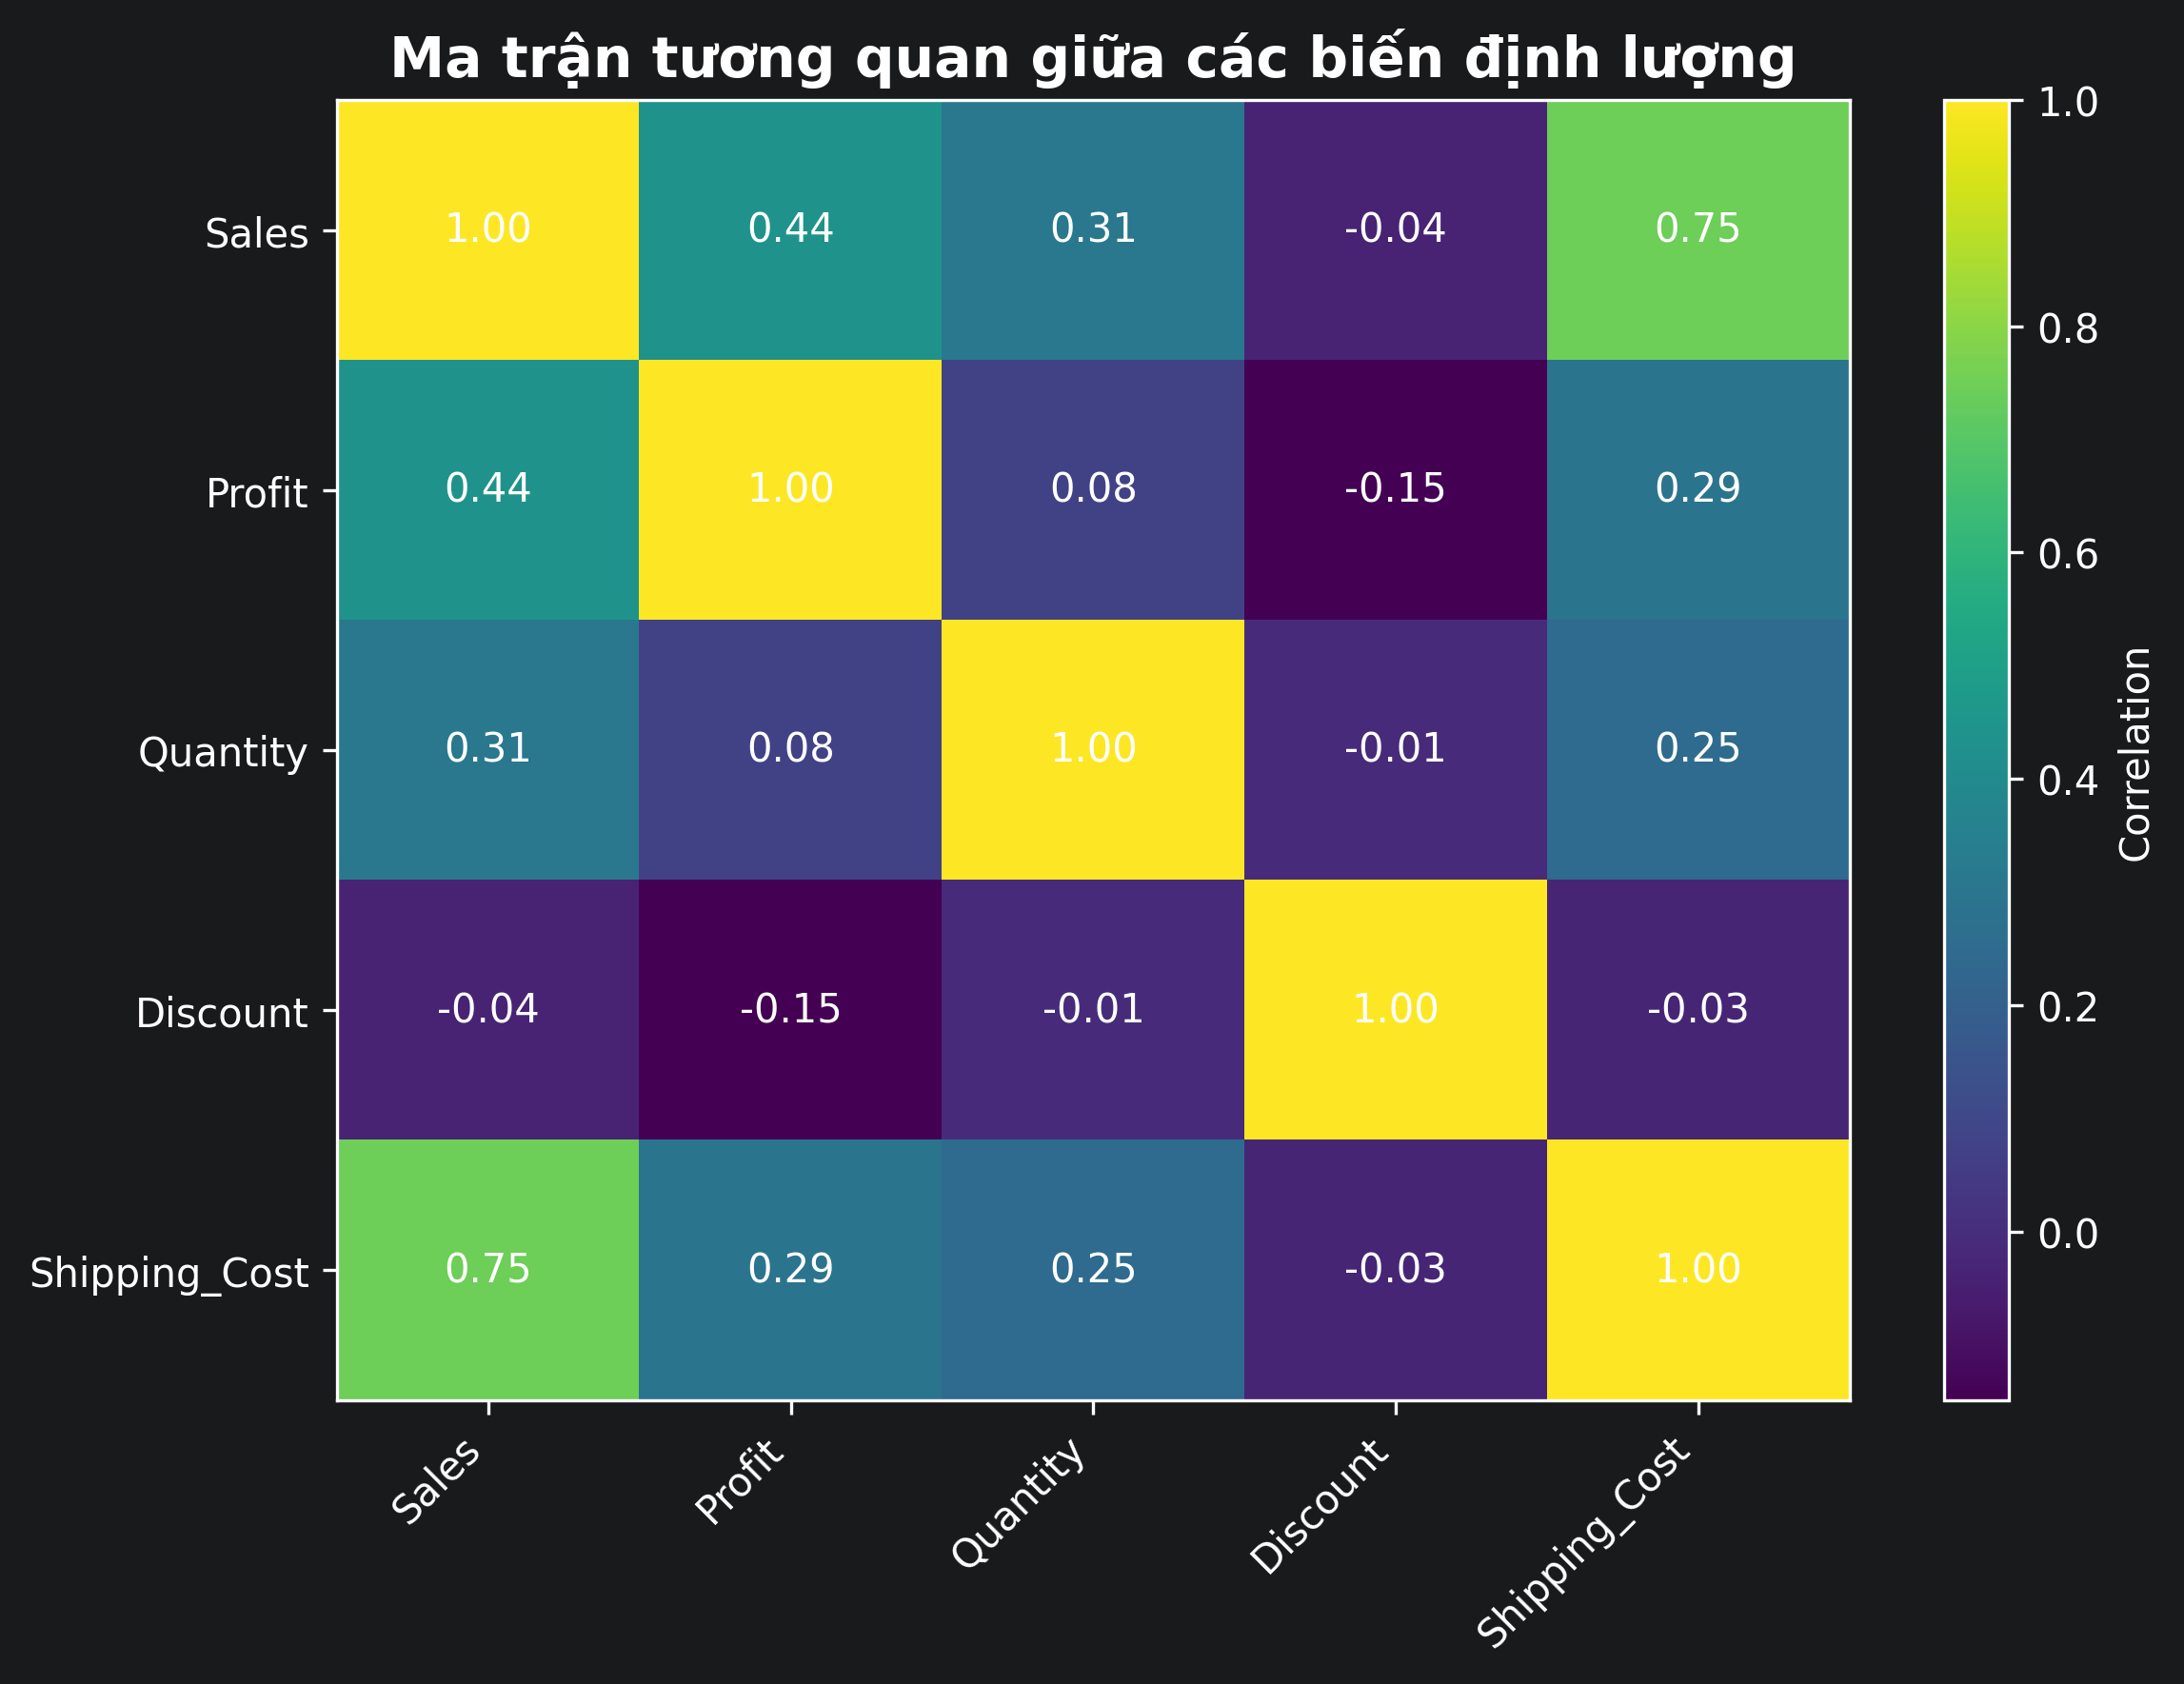

Đã lưu: C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_correlation_matrix.png


In [10]:
corr_cols = ["Sales", "Profit", "Quantity", "Discount", "Shipping_Cost"]

corr_matrix = pd.DataFrame(
    index=corr_cols,
    columns=corr_cols,
    dtype=float
)

for c1 in corr_cols:
    for c2 in corr_cols:
        corr_matrix.loc[c1, c2] = df_eda.stat.corr(c1, c2)

display(corr_matrix.round(4))

plt.figure(figsize=(8, 6), dpi=300)
plt.imshow(corr_matrix.astype(float), aspect="auto")

plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Ma trận tương quan giữa các biến định lượng", fontsize=14, fontweight="bold")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

output_path = os.path.join(OUTPUT_DIR, "eda_correlation_matrix.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu:", output_path)

In [11]:
eda_images = [
    "eda_market_sales.png",
    "eda_category_sales_profit.png",
    "eda_segment_sales.png",
    "eda_monthly_sales_profit_trend.png",
    "eda_discount_avg_profit.png",
    "eda_correlation_matrix.png"
]

for img in eda_images:
    print(os.path.join(OUTPUT_DIR, img))

C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_market_sales.png
C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_category_sales_profit.png
C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_segment_sales.png
C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_monthly_sales_profit_trend.png
C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_discount_avg_profit.png
C:\sourcecode\Nhom_10_Big_Data\images\eda\eda_correlation_matrix.png
